## 1. Analisis Permasalahan


A. Masalah yang Ditemukan

Berdasarkan dokumen proyek dan dataset yang dikirim, ada lima masalah utama pada proyek ini,antara lain :
1. Pencari kerja bingung menentukan arah karir karena memiliki skill tapi tidak tahu pekerjaan apa yang cocok. Sebagai contoh, mahasiswa yang menguasai Python dan SQL tidak mengetahui bahwa skill tersebut cocok untuk posisi Data Analyst atau Data Engineer.
2. Pencari kerja tidak tahu skill apa yang harus dipelajari lebih dulu ketika melihat lowongan Data Scientist yang membutuhkan 20 skill sementara mereka hanya memiliki 5 skill.
3. Terjadi ketidakcocokan antara skill yang dimiliki pencari kerja dengan skill yang dibutuhkan industri. Akibatnya perusahaan kesulitan mencari karyawan dan pencari kerja kesulitan mendapatkan pekerjaan.
4. Belum ada sistem yang memberikan rekomendasi dua arah. Sistem yang ada saat ini hanya menampilkan info lowongan tanpa memberikan arahan skill apa saja yang kurang untuk bisa melamar pekerjaan tertentu.
5. Dari sisi teknis, dataset yang tersedia sebenarnya lengkap karena memiliki kolom job title, deskripsi, dan skill. Namun format kolom skill masih berupa teks yang perlu dibersihkan terlebih dahulu sebelum dapat diproses oleh sistem.

B. Kondisi Dataset
Dataset yang digunakan dalam proyek ini memiliki struktur dan karakteristik sebagai berikut.
1. Terdapat lima kolom utama dalam dataset yaitu job_id, category, job_title, job_description, dan job_skill_set.
2. Kolom job_id berisi nomor unik untuk setiap pekerjaan dan jumlah baris dalam dataset mencapai ribuan entri.
3. Kolom category berisi kategori pekerjaan seperti HR, Information Technology, dan lainnya yang berguna untuk melakukan filtering rekomendasi.
4. Kolom job_title berisi nama pekerjaan spesifik seperti "Human Resources Generalist" atau "Data Scientist".
5. Kolom job_skill_set adalah kolom paling penting untuk sistem rekomendasi karena berisi daftar skill yang dibutuhkan dalam format list Python seperti ['Python', 'SQL', 'Machine Learning'], namun saat ini masih berupa string teks yang perlu diparsing terlebih dahulu.



C. Solusi yang Diusulkan
Berdasarkan lima masalah yang telah diidentifikasi, berikut adalah lima solusi yang akan diterapkan dalam proyek ini.
1. Melakukan normalisasi teks pada input skill pengguna dengan mengubah semua huruf menjadi kecil, menghapus spasi berlebih, dan memecah teks berdasarkan koma. Contohnya input "Python, SQL, Machine Learning" akan diubah menjadi list ['python', 'sql', 'machine learning'].
2. Mengubah daftar skill dari dataset dan skill pengguna menjadi vektor numerik menggunakan metode TF-IDF Vectorizer yang mampu menangani teks pendek seperti daftar skill.
3. Menghitung nilai kemiripan antara vektor skill pengguna dengan vektor skill setiap pekerjaan menggunakan metode Cosine Similarity yang menghasilkan nilai antara 0 hingga 1, dimana nilai yang mendekati 1 menandakan kemiripan yang tinggi.
4. Mengurutkan seluruh pekerjaan berdasarkan nilai similarity tertinggi ke terendah dan menampilkan 5 hingga 10 rekomendasi teratas kepada pengguna melalui dashboard.
5. Menghitung skill gap dengan membandingkan skill yang dimiliki pengguna terhadap skill yang dibutuhkan setiap pekerjaan, kemudian menampilkan skill yang belum dikuasai pengguna sebagai rekomendasi belajar.


# 2. Mendefinisikan Pertanyaan Bisnis


1. Apa saja 10 pekerjaan yang paling banyak tersedia berdasarkan jumlah lowongan di dataset?
2. Kategori pekerjaan mana yang memiliki jumlah lowongan terbanyak?
3. Apa saja 15 skill yang paling sering diminta oleh perusahaan di seluruh lowongan pekerjaan?
4. Bagaimana perbandingan jumlah hard skill dan soft skill yang diminta di pasar kerja?
5. Untuk kategori pekerjaan Data Science, apa saja 5 skill yang paling dominan diminta?
6. Untuk kategori pekerjaan HR, apa saja 5 skill yang paling dominan diminta?
7. Jika pengguna memiliki skill Excel, HR, dan Recruitment, pekerjaan apa yang paling sesuai dan berapa persen tingkat kecocokannya?
8. Skill apa saja yang perlu dipelajari pengguna untuk dapat bekerja sebagai HR Manager berdasarkan skill yang sudah dimilikinya?

# 3. Import Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('ggplot')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("Library berhasil diimport")

Library berhasil diimport


Kami memanggil semua library yang dibutuhkan untuk proyek ini. pandas dan numpy menjadi fondasi utama untuk mengolah data. ast dan re kami siapkan khusus untuk membersihkan teks dan mengubah format skill yang masih berantakan. Lalu kami memakai matplotlib dan seaborn untuk membuat visualisasi data nantinya. *collections.Counter* akan membantu menghitung frekuensi skill yang paling banyak diminta.
Terakhir, kami mengatur gaya tampilan grafik menjadi ggplot dan warna palet viridis. Ukuran figur grafik juga kami setel agar lebih lebar dan nyaman dilihat.

# 4. Data Warngling

#### Gathering Data


In [ ]:
import pandas as pd

df = pd.read_csv('all_job_post.csv')
df.head()

,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\r\nTHE SR. HR GENERALIST PROVIDES HR E...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\r\n\r\n WHO WE ARE \r\n\r\nAVI-SPL...,"['Microsoft Office', 'Data analysis', 'Employe..."


Dan membaca file CSV all_job_post.csv menggunakan pandas dan menyimpannya ke dalam variabel df. Perintah *df.head()* kemudian menampilkan 5 baris pertama dari dataset. Langkah ini penting untuk memahami struktur awal data: kolom apa saja yang tersedia *(job_id, category, job_title, job_description, job_skill_set) *dan seperti apa isi perkiraannya.

#### Assessing Data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_id           1167 non-null   int64
 1   category         1167 non-null   str  
 2   job_title        1167 non-null   str  
 3   job_description  1167 non-null   str  
 4   job_skill_set    1167 non-null   str  
dtypes: int64(1), str(4)
memory usage: 4.7 MB


Kemudian menggunakan df.info() untuk melihat ringkasan teknis dari dataset.

In [ ]:
df.isna().sum()

job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64

Kemudian kami memeriksa apakah ada nilai kosong (null) di setiap kolom. Fungsi isna() mendeteksi sel yang kosong, lalu .sum() menjumlahkannya per kolom. Hasilnya menunjukkan angka 0 di semua kolom.

In [ ]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Dan mengecek apakah ada baris data yang terduplikasi sempurna. Perintah df.duplicated() akan menandai baris mana saja yang merupakan salinan persis dari baris sebelumnya, lalu .sum() menghitung totalnya.

In [ ]:
df['category'].unique()

<ArrowStringArray>
['HR', 'INFORMATION-TECHNOLOGY', 'SALES', 'FINANCE', 'BUSINESS-DEVELOPMENT']
Length: 5, dtype: str

Kemudian untuk melihat semua kategori pekerjaan yang tersedia dalam dataset. Perintah .unique() pada kolom category menampilkan setiap nilai unik tanpa pengulangan.

In [ ]:
df['category'].nunique()

5

Kemudian untuk melihat semua kategori pekerjaan yang tersedia dalam dataset. Perintah .unique() pada kolom category menampilkan setiap nilai unik tanpa pengulangan.

In [ ]:
df['job_title'].str.lower().str.strip().head()

0                sr human resource generalist
1                     human resources manager
2                 director of human resources
3               chief human resources officer
4    human resources generalist (hybrid role)
Name: job_title, dtype: str

Kemudian kami melakukan pembersihan kolom job_title dengan mengubah semua huruf menjadi kecil semua menggunakan .lower(), lalu menghapus spasi di awal dan akhir dengan .strip(). Perintah .head() di akhir hanya menampilkan 5 baris pertama sebagai sampel.

In [ ]:
df['job_description'].str.len().describe()

count     1167.000000
mean      3787.388175
std       2115.749357
min        167.000000
25%       2126.500000
50%       3461.000000
75%       4961.500000
max      13689.000000
Name: job_description, dtype: float64

Kami menghitung panjang teks setiap deskripsi pekerjaan menggunakan .str.len(), lalu .describe() menampilkan statistik ringkasannya.

In [ ]:
df['category'].value_counts()

category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                        220
Name: count, dtype: int64

Dan kemudian kami menghitung berapa banyak lowongan yang tersedia di setiap kategori pekerjaan. Perintah value_counts() pada kolom category akan mengelompokkan dan menjumlahkan frekuensi setiap kategori, lalu mengurutkannya dari yang terbanyak ke tersedikit.

### Cleaning Data

In [ ]:
df['job_title'] = df['job_title'].str.lower().str.strip()
df['job_description'] = df['job_description'].str.lower().str.strip()
df['job_skill_set'] = df['job_skill_set'].str.lower().str.strip()
df['category'] = df['category'].str.lower().str.strip()

Standardisasi teks
Empat kolom utama langsung dibersihkan sekaligus: job_title, job_description, job_skill_set, dan category. Pertama, semua huruf diubah menjadi kecil menggunakan .lower() agar tidak ada perbedaan antara "Python", "python", atau "PYTHON". Kedua, spasi di awal dan akhir teks dihilangkan dengan .strip().

In [ ]:
cols = ['job_title', 'job_description', 'job_skill_set', 'category']

for col in cols:
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

Membersihkan double spasi pada setiap kolom
Keempat kolom dimasukkan ke dalam satu daftar bernama cols, lalu dilakukan perulangan untuk membersihkan masing-masing kolom. Fungsi str.replace(r'\s+', ' ', regex=True) bekerja mencari satu atau lebih spasi beruntun (\s+) dan menggantinya dengan satu spasi saja.

In [ ]:
df['category'] = df['category'].str.replace('-', ' ')

Merapihkan format category. Kolom category masih memiliki tanda hubung pada beberapa nilai, misalnya "information-technology" dan "business-development". Perintah ini mengganti semua tanda hubung (-) menjadi spasi ().

In [ ]:
df['job_description'] = df['job_description'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x.replace('\n', ' '))
)

Menghapus simbol pada job_description. Empat kolom utama langsung dibersihkan sekaligus: job_title, job_description, job_skill_set, dan category

In [ ]:
def parse_skill_column(skill_str):
    if pd.isna(skill_str):
        return []
    try:
        if isinstance(skill_str, str):
            return ast.literal_eval(skill_str)
        else:
            return []
    except:
        return []

df['job_skill_set_parsed'] = df['job_skill_set'].apply(parse_skill_column)
df['num_skills'] = df['job_skill_set_parsed'].apply(len)

print("Contoh hasil parsing:")
print(df[['job_title', 'job_skill_set_parsed', 'num_skills']].head(3))

Contoh hasil parsing:
                      job_title  \
0  sr human resource generalist   
1       human resources manager   
2   director of human resources   

                                job_skill_set_parsed  num_skills  
0  [employee relations, talent acquisition, perfo...          27  
1  [talent acquisition, employee performance mana...          16  
2  [human resources management, recruitment, empl...          20  


Fungsi *parse_skill_column* dibuat untuk menangani konversi data skill. Fungsi ini memeriksa apakah data kosong dengan pd.isna(), lalu mencoba mengubah string teks seperti "['Python', 'SQL']" menjadi list Python sungguhan menggunakan ast.literal_eval. Jika gagal atau formatnya salah, fungsi mengembalikan list kosong.

# 5.  Melakukan Exploratory Data Analysis (EDA)

In [ ]:
#Statistik Jumlah Skill Per pekerjaan
print(f"Rata-rata skill per pekerjaan: {df['num_skills'].mean():.2f}")
print(f"Minimum skill: {df['num_skills'].min()}")
print(f"Maksimum skill: {df['num_skills'].max()}")

Rata-rata skill per pekerjaan: 17.85
Minimum skill: 5
Maksimum skill: 43


Tiga informasi utama dihitung dari kolom *num_skills*. Rata-rata skill per pekerjaan menunjukkan nilai tengah dari seluruh data. Minimum skill menampilkan pekerjaan dengan persyaratan skill paling sedikit. Maksimum skill menampilkan pekerjaan dengan persyaratan skill paling banyak.

In [ ]:
#Analisis Kategori Pekerjaan
category_counts = df['category'].value_counts()
print("Jumlah lowongan per kategori:")
print(category_counts)

Jumlah lowongan per kategori:
category
information technology    240
business development      239
finance                   236
sales                     232
hr                        220
Name: count, dtype: int64


Kemudian memakai *value_counts()* pada kolom category untuk menghitung frekuensi setiap kategori pekerjaan. Hasilnya disimpan dalam variabel category_counts, kemudian dicetak ke layar. Data terurut otomatis dari kategori dengan lowongan terbanyak ke tersedikit

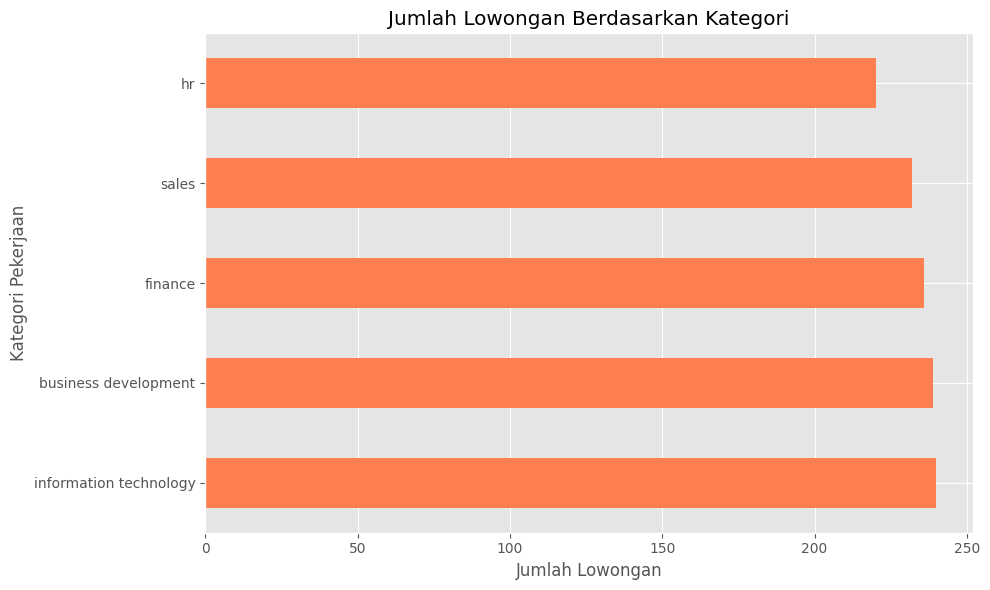

In [ ]:
#Visualisasi Kategori Pekerjaan
plt.figure(figsize=(10, 6))
category_counts.plot(kind='barh', color='coral')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Kategori Pekerjaan')
plt.title('Jumlah Lowongan Berdasarkan Kategori')
plt.tight_layout()
plt.show()

Grafik batang horizontal dibuat untuk menampilkan jumlah lowongan per kategori. Ukuran figur diatur menjadi lebar 10 dan tinggi 6 inci. Warna coral dipilih untuk batang agar terlihat mencolok. Sumbu X diberi label "Jumlah Lowongan", sumbu Y diberi label "Kategori Pekerjaan", dan judul grafik "Jumlah Lowongan Berdasarkan Kategori". *tight_layout()* merapikan tata letak elemen, lalu grafik ditampilkan.

In [ ]:
#Analisis Job Berdasarkan Popularitas
jobtitle_counts = df['job_title'].value_counts().head(10)
print("10 Job Title dengan lowongan terbanyak:")
print(jobtitle_counts)

10 Job Title dengan lowongan terbanyak:
job_title
business development manager                 53
human resources generalist                   34
business development representative          33
human resources manager                      29
information technology support specialist    16
human resources business partner             15
finance manager                              15
director of finance                          13
human resources coordinator                  11
information technology project manager       11
Name: count, dtype: int64


*value_counts()* menghitung frekuensi setiap judul pekerjaan di kolom job_title. *.head(10)* mengambil sepuluh nilai teratas yang paling sering muncul. Hasilnya dicetak untuk mengetahui posisi pekerjaan apa yang paling banyak dibutuhkan di pasar.

In [ ]:
#Kumpulkan semua skill dari dataset
all_skills = []
for skill_list in df['job_skill_set_parsed']:
    all_skills.extend(skill_list)

print(f"Total skill unik: {len(set(all_skills))}")
print(f"Total kemunculan skill: {len(all_skills)}")

Total skill unik: 4984
Total kemunculan skill: 20833


List kosong *all_skills* dibuat untuk menampung seluruh skill dari semua pekerjaan. Perulangan for berjalan melalui setiap baris kolom *job_skill_set_parsed,* lalu extend() menambahkan semua skill dari satu pekerjaan ke dalam list utama.



In [ ]:
#Skill Paling Banyak Diminta
skill_counts = Counter(all_skills).most_common(15)
print("15 Skill paling banyak diminta:")
for skill, count in skill_counts:
    print(f"  {skill}: {count} lowongan")

15 Skill paling banyak diminta:
  communication: 1092 lowongan
  problem solving: 878 lowongan
  adaptability: 588 lowongan
  teamwork: 569 lowongan
  collaboration: 341 lowongan
  leadership: 325 lowongan
  time management: 316 lowongan
  interpersonal skills: 288 lowongan
  customer service: 272 lowongan
  relationship building: 267 lowongan
  attention to detail: 253 lowongan
  data analysis: 251 lowongan
  project management: 234 lowongan
  organizational skills: 231 lowongan
  negotiation: 157 lowongan


*Counter(all_skills)* menghitung frekuensi kemunculan setiap skill dari list all_skills. *.most_common(15)* mengambil 15 skill dengan jumlah permintaan tertinggi. Perulangan for kemudian mencetak setiap skill beserta jumlah lowongan yang memintanya.

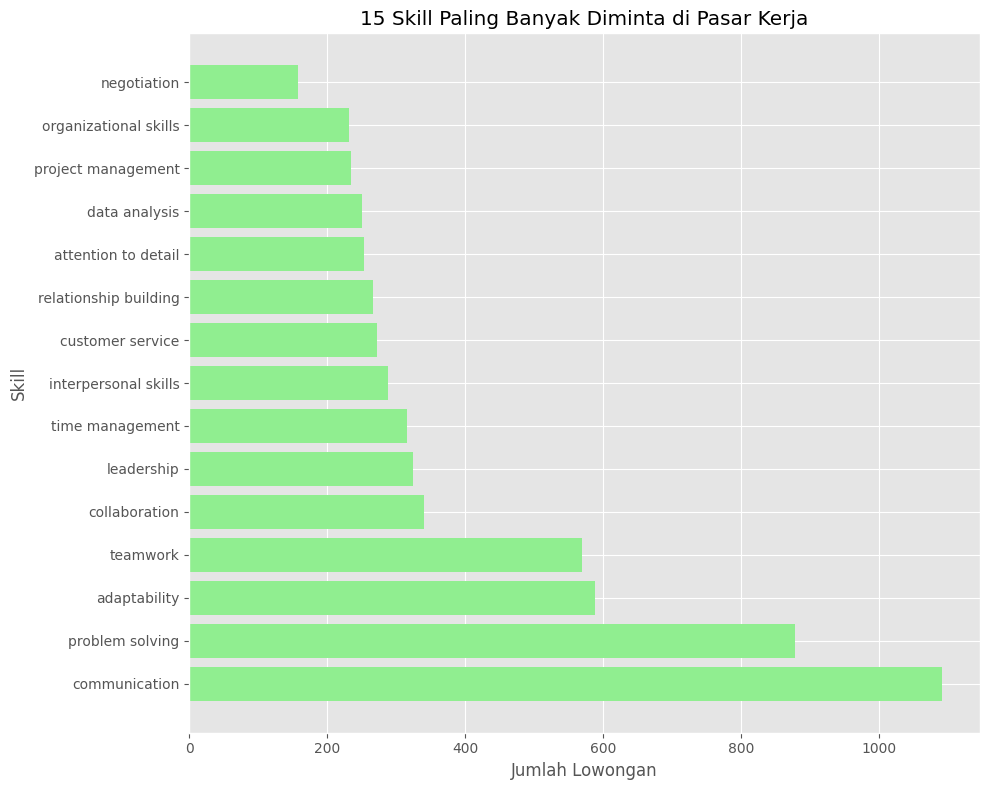

In [ ]:
# Visualisasi 15 Skill Paling Banyak Diminta
skills, counts = zip(*skill_counts)
plt.figure(figsize=(10, 8))
plt.barh(skills, counts, color='lightgreen')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.title('15 Skill Paling Banyak Diminta di Pasar Kerja')
plt.tight_layout()
plt.show()

zip(*skill_counts) memisahkan pasangan skill dan jumlahnya menjadi dua tuple terpisah: skills berisi nama skill, counts berisi jumlah lowongan. Ukuran figur diatur lebar 10 dan tinggi 8 inci. Grafik batang horizontal dibuat dengan warna lightgreen.

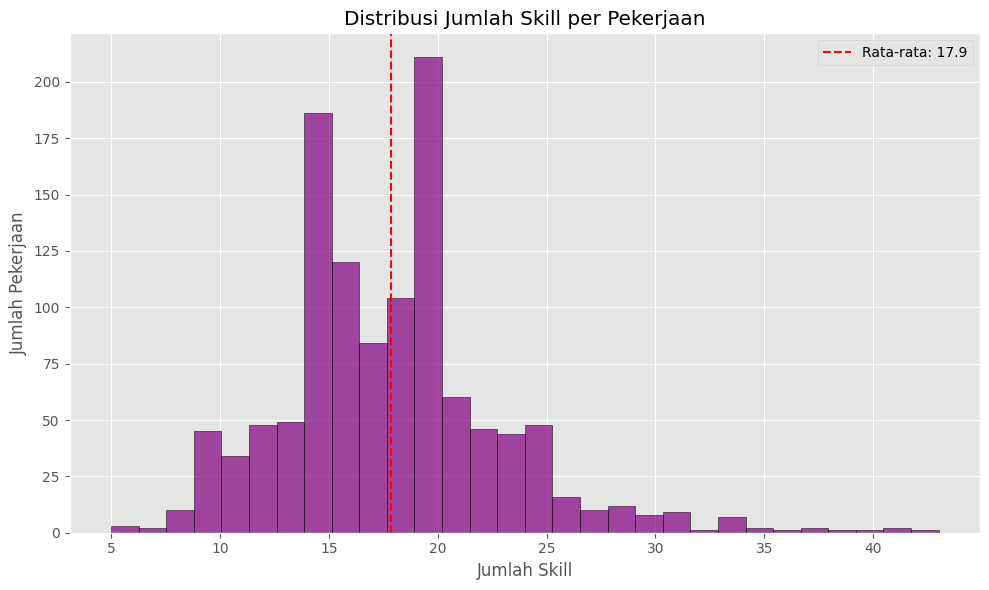

In [ ]:
# Histogram Distribusi Jumlah Skill per Pekerjaan
plt.figure(figsize=(10, 6))
plt.hist(df['num_skills'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Jumlah Skill')
plt.ylabel('Jumlah Pekerjaan')
plt.title('Distribusi Jumlah Skill per Pekerjaan')
plt.axvline(df['num_skills'].mean(), color='red', linestyle='dashed', label=f'Rata-rata: {df["num_skills"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

Histogram dibuat untuk melihat sebaran jumlah skill di semua lowongan. *plt.hist()* menggunakan kolom num_skills dengan 30 interval (bins). Warna batang purple dengan tepi black dan tingkat transparansi 0.7. Sumbu X diberi label "Jumlah Skill", sumbu Y "Jumlah Pekerjaan", dan judul "Distribusi Jumlah Skill per Pekerjaan"

In [ ]:
df_hr = df[df['category'] == 'hr']

all_skills_hr = []
for skill_list in df_hr['job_skill_set_parsed']:
    all_skills_hr.extend(skill_list)

skill_counts_hr = Counter(all_skills_hr).most_common(10)

print("10 Skill paling banyak diminta di kategori HR:")
for skill, count in skill_counts_hr:
    print(f"  {skill}: {count} lowongan")

10 Skill paling banyak diminta di kategori HR:
  communication: 207 lowongan
  problem solving: 171 lowongan
  employee relations: 102 lowongan
  adaptability: 102 lowongan
  teamwork: 101 lowongan
  interpersonal skills: 99 lowongan
  attention to detail: 81 lowongan
  performance management: 79 lowongan
  data analysis: 76 lowongan
  leadership: 72 lowongan


Data difilter terlebih dahulu dengan *df[df['category'] == 'hr']* untuk mengambil hanya lowongan dari kategori HR. List kosong all_skills_hr dibuat untuk menampung skill dari kategori tersebut. Perulangan berjalan melalui setiap baris *job_skill_set_parsed* dan extend() menambahkan semua skill ke dalam list.

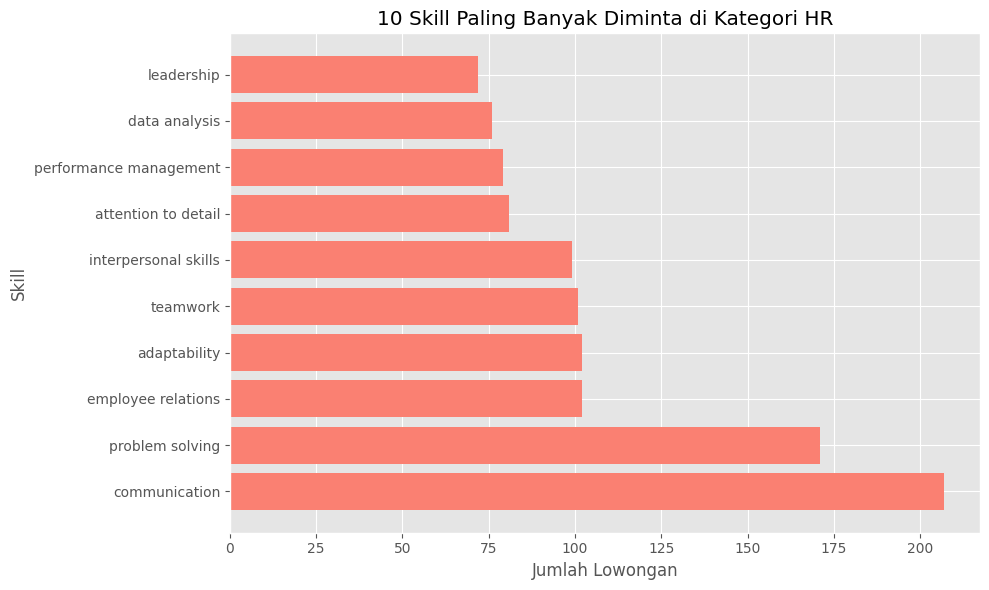

In [ ]:
# Visualisasi Skill Kategori HR
skills_hr, counts_hr = zip(*skill_counts_hr)
plt.figure(figsize=(10, 6))
plt.barh(skills_hr, counts_hr, color='salmon')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.title('10 Skill Paling Banyak Diminta di Kategori HR')
plt.tight_layout()
plt.show()

 Selanjutnya kami melakukan, zip(*skill_counts_hr) * *italicised text*italicised text* memisahkan pasangan skill dan jumlahnya menjadi dua tuple: skills_hr berisi nama skill, counts_hr berisi jumlah lowongan.

In [ ]:
# Analisis Skill Kategori Information Technology

df_it = df[df['category'] == 'information technology']

all_skills_it = []
for skill_list in df_it['job_skill_set_parsed']:
    all_skills_it.extend(skill_list)

skill_counts_it = Counter(all_skills_it).most_common(10)

print("10 Skill paling banyak diminta di kategori Information Technology:")
for skill, count in skill_counts_it:
    print(f"  {skill}: {count} lowongan")

10 Skill paling banyak diminta di kategori Information Technology:
  communication: 219 lowongan
  problem solving: 191 lowongan
  adaptability: 112 lowongan
  teamwork: 101 lowongan
  collaboration: 88 lowongan
  project management: 84 lowongan
  leadership: 69 lowongan
  customer service: 66 lowongan
  time management: 57 lowongan
  attention to detail: 51 lowongan


Data difilter dengan *df[df['category'] ==* 'information technology'] untuk mengambil hanya lowongan dari kategori IT. List kosong all_skills_it dibuat untuk menampung skill dari kategori tersebut. Perulangan berjalan melalui setiap baris *job_skill_set_parsed* dan extend() menambahkan semua skill ke dalam list.

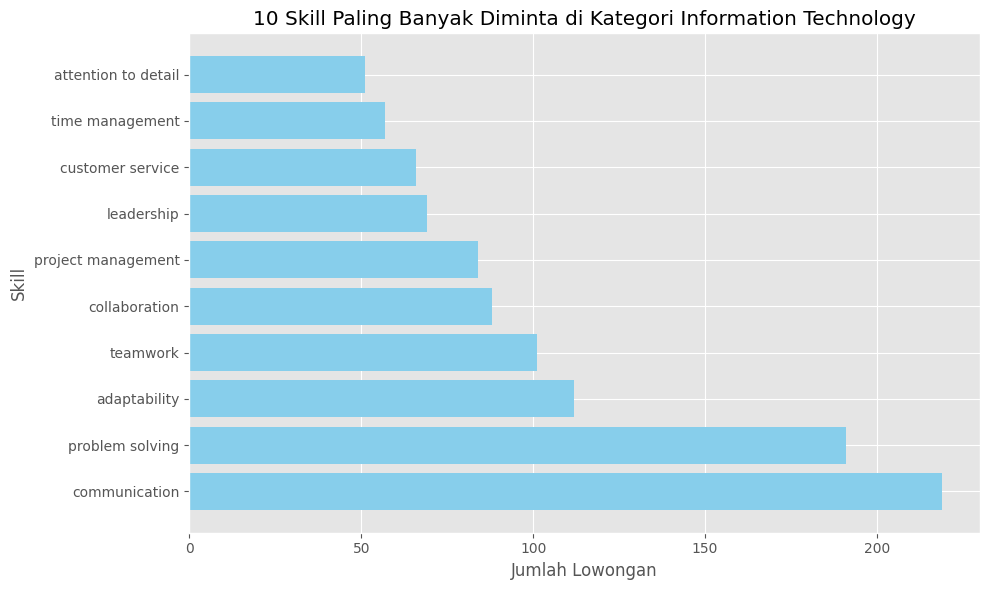

In [ ]:
# Visualisasi Skill Kategori Information Technology
skills_it, counts_it = zip(*skill_counts_it)
plt.figure(figsize=(10, 6))
plt.barh(skills_it, counts_it, color='skyblue')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.title('10 Skill Paling Banyak Diminta di Kategori Information Technology')
plt.tight_layout()
plt.show()

*zip(*skill_counts_it)* memisahkan pasangan skill dan jumlahnya menjadi dua tuple: skills_it berisi nama skill, counts_it berisi jumlah lowongan. Ukuran figur diatur lebar 10 dan tinggi 6 inci. Grafik batang horizontal

In [ ]:
# Ringkasan Akhir EDA
print("="*50)
print("RINGKASAN AKHIR EKSPLORASI DATA")
print("="*50)

print(f"1. Total lowongan dalam dataset: {len(df)}")
print(f"2. Jumlah kategori pekerjaan unik: {df['category'].nunique()}")
print(f"3. Kategori dengan lowongan terbanyak: {category_counts.index[0]} ({category_counts.iloc[0]} lowongan)")
print(f"4. Job title dengan lowongan terbanyak: {jobtitle_counts.index[0]} ({jobtitle_counts.iloc[0]} lowongan)")
print(f"5. Skill paling banyak diminta secara keseluruhan: {skill_counts[0][0]} ({skill_counts[0][1]} lowongan)")
print(f"6. Rata-rata jumlah skill per pekerjaan: {df['num_skills'].mean():.2f}")
print(f"7. Total skill unik dalam dataset: {len(set(all_skills))}")
print(f"8. Kategori HR memiliki skill terbanyak: {skill_counts_hr[0][0]} ({skill_counts_hr[0][1]} lowongan)")
print(f"9. Kategori IT memiliki skill terbanyak: {skill_counts_it[0][0]} ({skill_counts_it[0][1]} lowongan)")

RINGKASAN AKHIR EKSPLORASI DATA
1. Total lowongan dalam dataset: 1167
2. Jumlah kategori pekerjaan unik: 5
3. Kategori dengan lowongan terbanyak: information technology (240 lowongan)
4. Job title dengan lowongan terbanyak: business development manager (53 lowongan)
5. Skill paling banyak diminta secara keseluruhan: communication (1092 lowongan)
6. Rata-rata jumlah skill per pekerjaan: 17.85
7. Total skill unik dalam dataset: 4984
8. Kategori HR memiliki skill terbanyak: communication (207 lowongan)
9. Kategori IT memiliki skill terbanyak: communication (219 lowongan)


Bagian ini merangkum semua temuan penting dari proses eksplorasi data. Garis pemisah `"="*50` dibuat agar tampilan rapi. Sembilan poin informasi dicetak:

1. Total lowongan = jumlah baris dalam DataFrame
2. Jumlah kategori unik = 5 kategori
3. Kategori dengan lowongan terbanyak (dari `category_counts`)
4. Job title paling populer (dari `jobtitle_counts`)
5. Skill paling banyak diminta secara keseluruhan (dari `skill_counts`)
6. Rata-rata skill per pekerjaan (dari `num_skills`)
7. Total skill unik di seluruh dataset
8. Skill teratas di kategori HR
9. Skill teratas di kategori IT

Semua data ini sudah dihitung dari langkah-langkah sebelumnya dan sekarang ditampilkan sekaligus untuk memudahkan pembacaan kesimpulan.

# 6. Export Clean DataFrame

In [ ]:
#df.to_csv('../../data/processed/cleaned_all_job.csv', index=False)

Menyimpan DataFrame yang sudah dibersihkan ke file CSV (dikomentari, tidak dijalankan).